In [19]:
import requests
import os
import re
import pymupdf as ppdf
import base64
import operator
import pip_system_certs
from dotenv import load_dotenv,find_dotenv
from pathlib import Path
from langchain_google_genai.chat_models import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate,ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing import TypedDict,Annotated
from pydantic import BaseModel,Field

In [20]:
load_dotenv(find_dotenv())

RAPID_API_KEY = os.getenv('RAPID_API_KEY')
GOOGLE_API_KEY = os.getenv('GOOGLE_API_KEY')

print(f"Rapid Key Found: {RAPID_API_KEY is not None}")
print(f"Gemini Key Found: {GOOGLE_API_KEY is not None}")

Rapid Key Found: True
Gemini Key Found: True


In [21]:
llm=ChatGoogleGenerativeAI(model='gemini-2.5-flash')

# rag 

In [22]:


def extract_profile(text: str):
    lines = [l.strip() for l in text.splitlines() if l.strip()]

    name = lines[0] if lines else None

    email = None
    phone = None

    for line in lines:
        if not email:
            m = re.search(r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}", line)
            if m:
                email = m.group()

        if not phone:
            m = re.search(r"\+?\d[\d\s\-]{8,}\d", line)
            if m:
                phone = m.group()

    return {
        "name": name,
        "email": email,
        "phone": phone,
    }


In [23]:


SECTIONS = {
    "PROJECTS",
    "SKILLS",
    "EDUCATION",
    "EXPERIENCE",
    "CERTIFICATIONS",
    "INTERNSHIPS",
}

def sectionize_documents(docs):
    section_docs = []

    for doc in docs:
        current_section = "GENERAL"
        buffer = []

        for line in doc.page_content.splitlines():
            clean = line.strip()
            if not clean:
                continue

            if clean.upper() in SECTIONS:
                if buffer:
                    section_docs.append(
                        Document(
                            page_content="\n".join(buffer),
                            metadata={**doc.metadata, "section": current_section}
                        )
                    )
                current_section = clean.upper()
                buffer = []
            else:
                buffer.append(clean)

        if buffer:
            section_docs.append(
                Document(
                    page_content="\n".join(buffer),
                    metadata={**doc.metadata, "section": current_section}
                )
            )

    return section_docs


In [24]:
def load_documents(path:Path):
    loader=PyPDFLoader(
        str(path),
    )

    return loader.load()

In [25]:
def split_documents(documents):
    splitter=RecursiveCharacterTextSplitter(
        chunk_size=600,
        chunk_overlap=100,
        separators=["\n\n", "\n", " ", ""],
    )

    return splitter.split_documents(documents)

In [26]:
def create_vector_store(docs):
    embeddings = HuggingFaceEmbeddings(
        model_name="sentence-transformers/all-MiniLM-L6-v2"
    )
    return FAISS.from_documents(docs, embeddings)

def get_retriever(vs):
    return vs.as_retriever(search_kwargs={"k": 5})

In [27]:
def route_query(q: str):
    q = q.lower()
    if "name" in q:
        return "NAME"
    if "email" in q:
        return "EMAIL"
    if "phone" in q:
        return "PHONE"
    if "project" in q:
        return "PROJECTS"
    if "skill" in q:
        return "SKILLS"
    if "education" in q:
        return "EDUCATION"
    return "RAG"

In [28]:
class RAGSERVICE:

    def __init__(self, data_path: Path, llm):
        self.data_path = data_path
        self.llm = llm
        self.retriever = None
        self.profile = None

    def _build(self):
        docs = load_documents(self.data_path)
        if not docs:
            raise RuntimeError("No documents loaded")

        full_text = "\n".join(d.page_content for d in docs)
        self.profile = extract_profile(full_text)

        section_docs = sectionize_documents(docs)
        chunks = split_documents(section_docs)
        vs = create_vector_store(chunks)
        self.retriever = get_retriever(vs)

    def query(self, question: str):
        intent = route_query(question)

        if intent == "NAME":
            return self.profile["name"]

        if intent == "EMAIL":
            return self.profile["email"]

        if intent == "PHONE":
            return self.profile["phone"]

        docs = self.retriever.invoke(question)
        context = "\n".join(d.page_content for d in docs)

        prompt = f"""
You are given resume content.

Context:
{context}

Question:
{question}

Answer concisely using ONLY the context.
"""

        return self.llm.invoke(prompt)

    def rebuild(self):
        self._build()


In [29]:
BASE_DIR = Path.cwd().parents[0] 
file_path= BASE_DIR / "data" / "Utkarsh_Singh_CV.pdf"

if not file_path.exists():
    raise FileNotFoundError(f"{file_path} not found")

llm = ChatGoogleGenerativeAI(model='gemini-2.5-flash')
rag=RAGSERVICE(file_path,llm)
rag._build()

In [30]:
print(rag.query('Projects?'))

content='*   **[Implicit Project related to Syntax-Rush repo]**\n    *   Description: Solutions across users and problems. Tech stack (ML side): Python, FastAPI, PyTorch, Hugging Face Transformers (GPT 2), AST, Git, Docker.\n    *   Repository Link: https://github.com/dhruv086/syntax-rush\n*   **Comic Chat** (Sep’ 25)\n    *   Description: GenAI-powered comic knowledge bot using RAG and LLM reasoning to answer comics lore and character queries.\n    *   Repository Link: https://github.com/UtkarshSingh31/Segma' additional_kwargs={} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019c8658-45b7-71e3-8dd1-e7322d9bcfa0-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 427, 'output_tokens': 669, 'total_tokens': 1096, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 529}}


# Graph state

In [32]:
class Resume_basic(TypedDict):

    resume_sections:list[str]
    file_path: str
    job_role:str
    job_level:str
    image_base64:str
    ats_score:int
    recommendations:Annotated[list[str],operator.add]
    job_openings:Annotated[list[str],operator.add]
    grammer_errors:Annotated[list[str],operator.add]


# resume sections

In [33]:
def resume_sections(state:Resume_basic):
    return {'resume_sections':SECTIONS}

# job role and level

In [34]:
def job_role(state:Resume_basic):
    jr=state.get('job_role')
    
    return {'job_role':jr}

In [35]:
def job_level(state:Resume_basic):
    jl=state.get('job_level')

    return {'job_level':jl}

# upload and convert from pdf to image

In [36]:
def upload_and_convert(state:Resume_basic):
    """
    Takes the file_path from state, converts PDF to image, 
    and returns the base64 string to update the state.
    """
    pdf_path=state.get('file_path')
    if not pdf_path:
        raise FileNotFoundError('No file is there')
    
    doc=ppdf.open(pdf_path)
    page=doc.load_page(0) # process first page.
    
    # increase resolution.
    mat = ppdf.Matrix(2.0, 2.0)
    pix=page.get_pixmap(matrix=mat)

    # convert to bytes directly in memory
    img_bytes=pix.tobytes('png')
    encoded_string=base64.b64encode(img_bytes).decode('utf-8')

    return {"image_base64":encoded_string}
    


# ats score

In [37]:
def calculate_ats_score(state:Resume_basic):
    
    image_coded=state.get('image_base64')
    if not image_coded:
        raise FileNotFoundError('No file encoded for given pdf.')

    system_instruction="""You are a 2026-era context-aware Applicant Tracking System (ATS)
used in real hiring pipelines across all industries.

Target Role: {job_title}
Target Seniority: {job_level}

You do NOT assume any specific domain. You evaluate resumes strictly based on the provided job_title and job_level...
You evaluate resumes strictly based on the provided job_title and job_level.

You will receive:
- resume_text OR resume_image
- job_title
- job_level (fresher | entry | mid | senior)

Your evaluation must adapt dynamically based on the job_title and job_level.

Contextual factors you must consider:
- Typical expectations for the given job_level
- Industry norms for the given job_title
- Market competitiveness for similar roles
- Balance between experience, projects, certifications, and education
- Evidence of impact, responsibility, or progression
- Resume clarity and ATS readability

Evaluation dimensions (weighted contextually, not equally):
1. Role relevance (skills and experience alignment to job_title)
2. Experience depth appropriate to job_level
3. Demonstrated impact or measurable contribution
4. Seniority alignment (underqualified or overqualified signals)
5. Resume structure and clarity for ATS parsing
6. Differentiation compared to an average candidate at that level

Scoring rules:
- Output an ATS Score between 0 and 100
- Score reflects likelihood of being shortlisted, not hired
- Scores below 70 indicate low shortlist probability
- Do NOT assume skills not explicitly present

Output format (STRICT):

ATS Score: <number>/100

Do NOT output anything else.

"""
    
    message=HumanMessage(
        content=[
           {"type": "text", "text": system_instruction}, 
            {
                "type": "image_url",
                "image_url": {"url": f"data:image/png;base64,{image_coded}"},
            },
        ]
    )


    response=llm.invoke([message])

    return {'ats_score':response.content}

    

# Recommedations

In [38]:
def give_recommendation(state:Resume_basic):
    image_coded = state.get('image_base64')
    job_title = state.get('job_role')
    job_level = state.get('job_level')

    recommendation_prompt = f"""
    You are an elite Tech Career Strategist and Executive Headhunter in 2026.
    Your task is to provide a surgical-grade improvement plan for a candidate's CV.

    TARGET CONTEXT:
    - Role: {job_title}
    - Level: {job_level}

    INSTRUCTIONS:
    1. Analyze the provided CV image against high-performance standards for {job_title}.
    2. Identify the 'Gap': What is missing that a {job_level} level hire MUST have?
    3. Strategy: Provide actionable advice to increase their ATS score and interview conversion.

    OUTPUT STRUCTURE (Strict):

    ### 🚀 Critical Gaps
    - [Identify a missing skill or experience required for {job_level}]
    - [Identify a formatting or structural weakness]

    ### 🛠️ Content Optimization
    - **Instead of:** "[Old phrase from CV]"
    - **Use:** "[New high-impact, metrics-driven phrase]"

    ### 📈 Strategic Recommendations
    - **Skill Acquisition:** What specific tool/cert should they get next?
    - **Project Framing:** How should they describe their work to sound more like a {job_level}?
    - **Formatting:** Specific layout changes for better parsing.

    ### 💡 2026 Competitive Edge
    - [One unique tip to stand out in the current job market for {job_title}]

    Tone: Candid, professional, and highly tactical. No fluff.
    """

    message = HumanMessage(
        content=[
            {"type": "text", "text": recommendation_prompt},
            {
                "type": "image_url",
                "image_url": {"url": f"data:image/png;base64,{image_coded}"},
            },
        ]
    )

    response = llm.invoke([message])
    return {"recommendations": response.content}

# Job openings

In [39]:
def job_openings(state:Resume_basic):
    job_title = state.get("job_role").replace("/"," ")
    job_level = state.get("job_level")

    url = "https://jsearch.p.rapidapi.com/search"

    querystring = {
        "query": f"{job_title} in India, {job_level} level",
        "page": "1",
        "num_pages": "1"
    }

    headers = {
        "X-RapidAPI-Key": RAPID_API_KEY,
        "X-RapidAPI-Host": "jsearch.p.rapidapi.com"
    }

    try:
        response = requests.get(url, headers=headers, params=querystring)
        response.raise_for_status()
        data = response.json()
        
        jobs = data.get('data', [])[:3] # Taking top 3 for the list
        
        job_list = []
        for job in jobs:
            title = job.get('job_title')
            company = job.get('employer_name')
            # JSearch usually provides a direct 'job_apply_link'
            link = job.get('job_apply_link')
            source = job.get('job_publisher', 'Job Board')
            
            job_list.append(f"**{title}**\n   🏢 {company} (via {source})\n   🔗 [Apply Directly]({link})")

        formatted_output = "\n\n".join(job_list) if job_list else "No active openings found for this role."
        
        return {"job_opening": formatted_output}

    except Exception as e:
        return {"job_openings": f"Job search failed: {str(e)}"}

# graph nodes and edges

In [42]:
graph=StateGraph(Resume_basic)

graph.add_node('upload_and_convert',upload_and_convert)
graph.add_node('job_role',job_role)
graph.add_node('job_level',job_level)
graph.add_node('resume_sections',resume_sections)
graph.add_node('calculate_ats_score',calculate_ats_score)
graph.add_node('give_recommendation',give_recommendation)
graph.add_node('job_openings',job_openings)

graph.add_edge(START,'upload_and_convert')
graph.add_edge('upload_and_convert','resume_sections')
graph.add_edge('resume_sections','job_role')
graph.add_edge('job_role','job_level')
graph.add_edge('job_level','calculate_ats_score')
graph.add_edge('job_level','give_recommendation')
graph.add_edge('job_level','job_openings')
graph.add_edge('job_openings',END)
graph.add_edge('give_recommendation',END)
graph.add_edge('calculate_ats_score',END)


In [43]:
workflow=graph.compile()

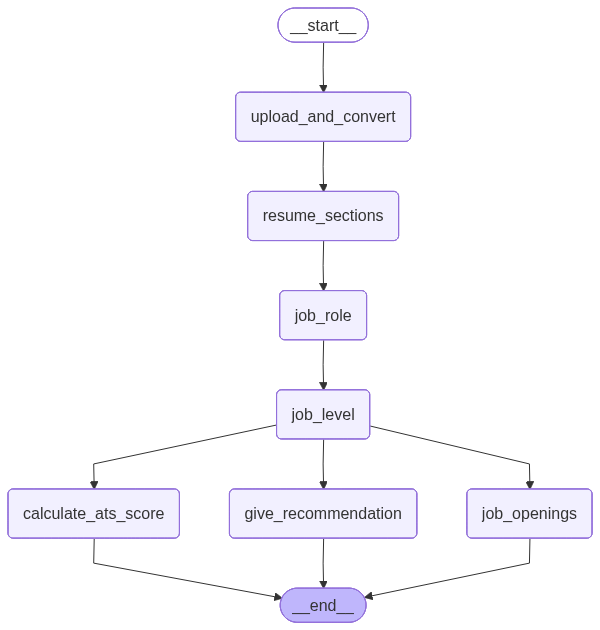

In [44]:
workflow

In [45]:
BASE_DIR = Path.cwd().parents[0] 
file_path= BASE_DIR / "data" / "Saurabh_CV.pdf"
file_path1=str(file_path)
file_path1

'e:\\resume_talk\\data\\Saurabh_CV.pdf'

In [ ]:
user_job = input("Enter the Job Title: ")
user_level = input("Enter the Job Level (fresher/entry/mid/senior): ")

initial_stage= {
    'file_path':file_path1,
    'job_role':user_job,
    'job_level':user_level
}

In [ ]:
result=workflow.invoke(initial_stage)

In [ ]:
print(result['job_role'])
print(result['job_level'])
print(result['ats_score'])
print(result['recommendation'])
print(result['job_opening'])